In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import math

In [2]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler,MinMaxScaler

In [3]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\CP 2\global greenhouse gas emissions from agriculture.csv")
df

,Area,Element,Year,Value
0,Afghanistan,Emissions (CH4),1990,214.4467
1,Afghanistan,Emissions (CH4),1991,224.1393
2,Afghanistan,Emissions (CH4),1992,226.7224
3,Afghanistan,Emissions (CH4),1993,228.5003
4,Afghanistan,Emissions (CH4),1994,236.9822
...,...,...,...,...
22211,Zimbabwe,Emissions (N2O),2017,15.4064
22212,Zimbabwe,Emissions (N2O),2018,15.4385
22213,Zimbabwe,Emissions (N2O),2019,15.0984
22214,Zimbabwe,Emissions (N2O),2020,13.4151


In [4]:
df.isnull().sum()

Area       0
Element    0
Year       0
Value      0
dtype: int64

In [5]:
area_encoder = LabelEncoder()
element_encoder = LabelEncoder()

df['Area'] = area_encoder.fit_transform(df['Area'].astype(str))
df['Element'] = element_encoder.fit_transform(df['Element'].astype(str))

In [6]:
x = df.drop(columns=['Value'])
y =df['Value']

In [7]:
df.columns

Index(['Area', 'Element', 'Year', 'Value'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22216 entries, 0 to 22215
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Area     22216 non-null  int64  
 1   Element  22216 non-null  int64  
 2   Year     22216 non-null  int64  
 3   Value    22216 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 694.4 KB


In [9]:
x

,Area,Element,Year
0,0,0,1990
1,0,0,1991
2,0,0,1992
3,0,0,1993
4,0,0,1994
...,...,...,...
22211,242,2,2017
22212,242,2,2018
22213,242,2,2019
22214,242,2,2020


In [10]:
y

0        214.4467
1        224.1393
2        226.7224
3        228.5003
4        236.9822
           ...   
22211     15.4064
22212     15.4385
22213     15.0984
22214     13.4151
22215     14.3762
Name: Value, Length: 22216, dtype: float64

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [12]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(x_test)

In [14]:
r2_score(y_test,y_pred)

0.0044578651856120866

In [15]:
mean_squared_error(y_test,y_pred)

5135798727.285475

In [16]:
mean_absolute_error(y_test,y_pred)

15035.282559259324

In [17]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
rmse

np.float64(71664.48721148763)

In [18]:
l1 = Lasso()
l1.fit(x_train,y_train)

Lasso()

In [19]:
y_pred_lasso = l1.predict(x_test)

In [20]:
print(r2_score(y_test,y_pred_lasso))
print(mean_absolute_error(y_test,y_pred_lasso))
print(mean_squared_error(y_test,y_pred_lasso))

0.004457792293294793
15035.288094191497
5135799103.322065


In [21]:
l2 = Ridge()
l2.fit(x_train,y_train)
y_pred_ridge = l2.predict(x_test)

In [22]:
print(r2_score(y_test,y_pred_ridge))
print(mean_absolute_error(y_test,y_pred_ridge))
print(mean_squared_error(y_test,y_pred_ridge))

0.004457865016852303
15035.282677613252
5135798728.156072


In [23]:
l12 = ElasticNet()
l12.fit(x_train,y_train)
y_pred_elasticnet = l12.predict(x_test)

In [24]:
print(r2_score(y_test,y_pred_elasticnet))
print(mean_absolute_error(y_test,y_pred_elasticnet))
print(mean_squared_error(y_test,y_pred_elasticnet))

0.0044537297734073
15035.876294917301
5135820061.033184


In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [26]:
knn = KNeighborsRegressor()
knn.fit(x_train, y_train)

KNeighborsRegressor()

In [27]:
y_pred_knn=knn.predict(x_test)

In [28]:
r2_score(y_test,y_pred_knn)

0.28603517753910435

In [29]:
x_train.shape

(17772, 3)

In [30]:
x_test.shape

(4444, 3)

In [31]:
y_train.shape

(17772,)

In [32]:
y_test.shape

(4444,)

In [33]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [34]:
y_pred_dt = dt.predict(x_test)

In [35]:
print(r2_score(y_test,y_pred_dt))
print(mean_absolute_error(y_test,y_pred_dt))
print(mean_squared_error(y_test,y_pred_dt))
# print(np.sqrt(mean_squared_error))

0.9884431689558124
475.44095966471656
59619333.11768653


In [36]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
y_pred_rf = rf.predict(x_test)

In [38]:
y_pred_lr = lr.predict(x_test)
y_pred_dt = dt.predict(x_test)
y_pred_rf = rf.predict(x_test)

In [39]:
results = []

models = {
    "Linear Regression": y_pred_lr,
    "Lasso (L1)": y_pred_lasso,
    "Ridge (L2)": y_pred_ridge,
    "ElasticNet (L1 + L2)": y_pred_elasticnet,
    "Decision Tree Regressor": y_pred_dt,
    "Random Forest Regressor": y_pred_rf
}

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "R² Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results)
results_df

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.004458,15035.282559,71664.487211
1,Lasso (L1),0.004458,15035.288094,71664.489835
2,Ridge (L2),0.004458,15035.282678,71664.487218
3,ElasticNet (L1 + L2),0.004454,15035.876295,71664.636056
4,Decision Tree Regressor,0.988443,475.440960,7721.355653
5,Random Forest Regressor,0.993156,439.483668,5941.873874


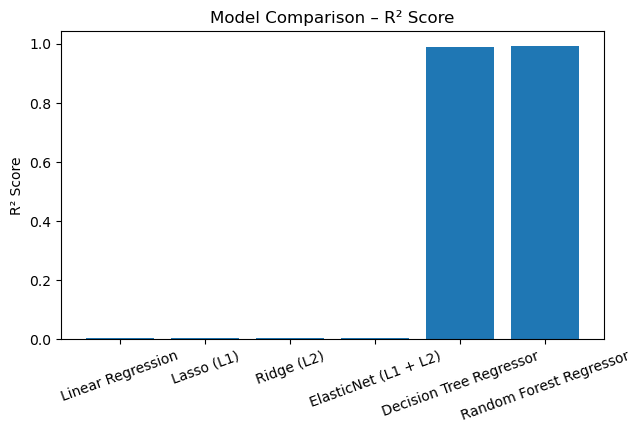

In [40]:
models = results_df["Model"]
r2 = results_df["R² Score"]

plt.figure(figsize=(7,4))
plt.bar(models, r2)
plt.title("Model Comparison – R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

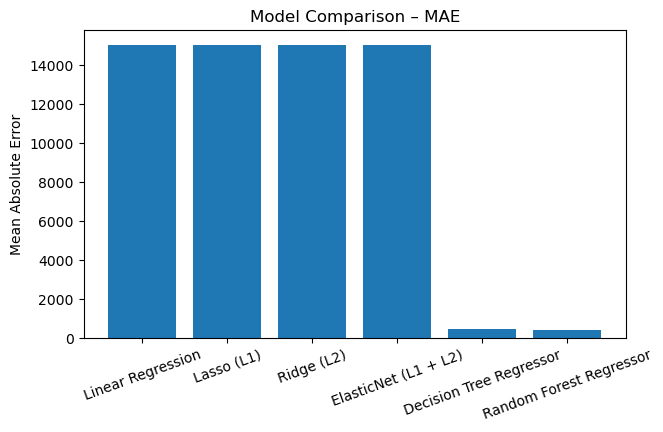

In [41]:
mae = results_df["MAE"]

plt.figure(figsize=(7,4))
plt.bar(models, mae)
plt.title("Model Comparison – MAE")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=20)
plt.show()

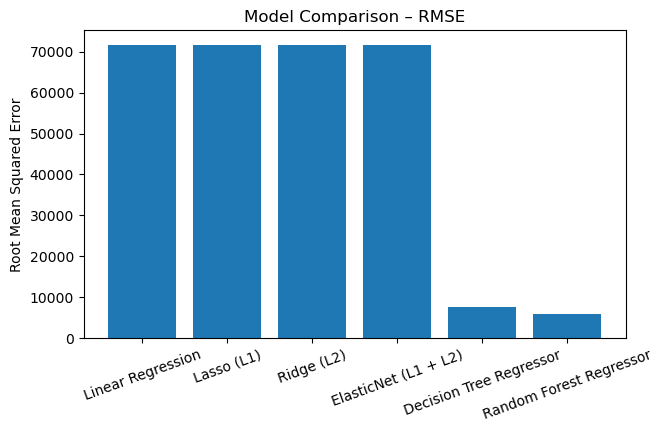

In [42]:
rmse = results_df["RMSE"]

plt.figure(figsize=(7,4))
plt.bar(models, rmse)
plt.title("Model Comparison – RMSE")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.show()

In [43]:
dt.score(x_train, y_train)

1.0

In [44]:
dt.score(x_test, y_test)

0.9884431689558124

In [45]:
rf.score(x_train, y_train)

0.994836997293572

In [46]:
rf.score(x_test, y_test)

0.9931561811083817

In [126]:
import pickle

pickle.dump(rf, open("random_forest.pkl", "wb"))
pickle.dump(area_encoder, open("area_encoder.pkl", "wb"))
pickle.dump(element_encoder, open("element_encoder.pkl", "wb"))

In [127]:
df_pivot = df.pivot_table(
    index=["Area", "Year"],
    columns="Element",
    values="Value",
    aggfunc="mean"
).reset_index()

In [128]:
df_pivot.columns

Index(['Area', 'Year', 0, 1, 2], dtype='object', name='Element')

In [129]:
df_pivot.head()

Element,Area,Year,0,1,2
0,0,1990,214.4467,14.2245,9.0765
1,0,1991,224.1393,11.3880,9.3494
2,0,1992,226.7224,9.2501,9.1762
3,0,1993,228.5003,9.0394,9.2855
4,0,1994,236.9822,8.3738,8.6996


In [130]:
# Remove the column index name
df_pivot.columns.name = None

# Rename numeric columns to gas names (VERY IMPORTANT)
df_pivot = df_pivot.rename(columns={
    0: "CH4",
    1: "CO2",
    2: "N2O"
})

df_pivot.columns

Index(['Area', 'Year', 'CH4', 'CO2', 'N2O'], dtype='object')

In [131]:
import numpy as np

df_pivot["Dominant_Gas"] = np.where(
    (df_pivot["CH4"] >= df_pivot["CO2"]) &
    (df_pivot["CH4"] >= df_pivot["N2O"]),
    "CH4",
    np.where(
        df_pivot["CO2"] >= df_pivot["N2O"],
        "CO2",
        "N2O"
    )
)

df_pivot[["Area", "Year", "CH4", "CO2", "N2O", "Dominant_Gas"]].head()

,Area,Year,CH4,CO2,N2O,Dominant_Gas
0,0,1990,214.4467,14.2245,9.0765,CH4
1,0,1991,224.1393,11.3880,9.3494,CH4
2,0,1992,226.7224,9.2501,9.1762,CH4
3,0,1993,228.5003,9.0394,9.2855,CH4
4,0,1994,236.9822,8.3738,8.6996,CH4


In [132]:
X = df_pivot[["CH4", "CO2", "N2O"]]
y = df_pivot["Dominant_Gas"]

In [133]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [134]:
from sklearn.metrics import classification_report

In [135]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       123
           1       1.00      1.00      1.00      1345
           2       1.00      1.00      1.00        16

    accuracy                           1.00      1484
   macro avg       1.00      0.99      1.00      1484
weighted avg       1.00      1.00      1.00      1484



In [136]:
print(X.shape)
print(y.shape)

(7416, 3)
(7416,)


In [137]:
X

,CH4,CO2,N2O
0,214.4467,14.2245,9.0765
1,224.1393,11.3880,9.3494
2,226.7224,9.2501,9.1762
3,228.5003,9.0394,9.2855
4,236.9822,8.3738,8.6996
...,...,...,...
7411,249.1567,11369.4740,15.4064
7412,252.7553,11464.9007,15.4385
7413,246.5412,11444.3787,15.0984
7414,231.9331,11305.5854,13.4151


In [138]:
y

0       CH4
1       CH4
2       CH4
3       CH4
4       CH4
       ... 
7411    CO2
7412    CO2
7413    CO2
7414    CO2
7415    CO2
Name: Dominant_Gas, Length: 7416, dtype: object

In [139]:
import pickle

pickle.dump(clf, open("dominant_gas_classifier.pkl", "wb"))
pickle.dump(le, open("dominant_gas_label_encoder.pkl", "wb"))

In [140]:
df.groupby("Element")["Value"].mean()

Element
0      659.444610
1    24734.006266
2       35.728036
Name: Value, dtype: float64